#Question_2

In [ ]:
# 2 Solution a)

In [16]:
def decimal_to_binary(decimal): 
    """
    Convert a decimal number to its binary equivalent.
    """
    if decimal == 0:
        return "0"

    sign = "-" if decimal < 0 else ""
    decimal = abs(decimal)

    integer_part = int(decimal)
    fractional_part = decimal - integer_part
    binary = ""
    if integer_part == 0:
        binary = "0"
    else:
        while integer_part > 0:
            binary = str(integer_part % 2) + binary
            integer_part //= 2

    if fractional_part:
        binary += "."
        for _ in range(32):  # Limit digits for fractions with repeating binary expansions
            fractional_part *= 2
            bit = int(fractional_part)
            binary += str(bit)
            fractional_part -= bit
            if fractional_part == 0:
                break

    return sign + binary
n= float(input("Enter a decimal number: "))
print(n , "in binary is: ",decimal_to_binary(n))

45.45 in binary is:  101101.01110011001100110011001100110011


In [ ]:
# ques_2b


In [14]:
import math
def decimal_to_ieee(num):
    if num == 0:
        return "0" * 32  # Special case for zero

    sign_bit = '0' if num >= 0 else '1'       # represented as s
    num = abs(num)

    exponent = 0
    while num >= 2:
        num /= 2
        exponent += 1
    while num < 1:
        num *= 2
        exponent -= 1

    exponent += 1023  # Bias for double precision      #represented as e
    exponent_bits = f"{exponent:011b}"

    mantissa = ""                                          #represented as m 
    num -= 1  # Remove the leading 1 for normalized numbers
    for _ in range(52):
        num *= 2
        if num >= 1:
            mantissa += '1'
            num -= 1
        else:
            mantissa += '0'

    ieee754_binary = sign_bit + (" = s") , exponent_bits + (" = e") , mantissa + (" = m")
    return ieee754_binary
n= float(input("Enter a number to convert to IEEE double precision: "))
print(n,"in IEEE is:", decimal_to_ieee(n))


8.342349234823884e+17 in IEEE is: ('0 = s', '10000111010 = e', '0111001001111001100001111100011000101100100100101111 = m')


#qus_2c

In [6]:
def ieee_to_decimal(s, e, f):
    sign_bit = str(s)
    exponent_bits = str(e)
    fraction_bits = str(f)

    if sign_bit not in {"0", "1"}:
        raise ValueError("Sign bit must be 0 or 1")
    if not exponent_bits or any(bit not in "01" for bit in exponent_bits):
        raise ValueError("Exponent must contain only 0 and 1 bits")
    if any(bit not in "01" for bit in fraction_bits):
        raise ValueError("Fraction must contain only 0 and 1 bits")

    exponent = int(exponent_bits, 2)
    fraction = int(fraction_bits, 2) if fraction_bits else 0
    exponent_max = (1 << len(exponent_bits)) - 1
    bias = (1 << (len(exponent_bits) - 1)) - 1

    if exponent == exponent_max:
        if fraction == 0:
            return float("-inf") if sign_bit == "1" else float("inf")
        return float("nan")

    if exponent == 0:
        if fraction == 0:
            return -0.0 if sign_bit == "1" else 0.0
        value = (fraction / (2 ** len(fraction_bits))) * (2 ** (1 - bias))
    else:
        value = (1 + fraction / (2 ** len(fraction_bits))) * (
            2 ** (exponent - bias)
        )

    if sign_bit == "1":
        value = -value

    return value


s = input("Enter the sign bit (0 or 1): ")
e = input("Enter the exponent bits: ")
f = input("Enter the fraction bits: ")

print("The decimal equivalent is:", ieee_to_decimal(s, e, f))

The decimal equivalent is: 7.202517429043684e+67


In [ ]:
#2d

In [1]:
import math

def decimal_to_ieee_double(x):
    """
    Definition used in 2b:
    Converts a decimal value to IEEE-754 double-precision format:
    (s, e, m)
    s = sign bit
    e = 11-bit exponent
    m = 52-bit mantissa
    """
    # Handle special values
    if math.isnan(x):
        return ('0', '11111111111', '0000000000000000000000000000000000000000000000000001')
    if math.isinf(x):
        s = '0' if x > 0 else '1'
        return (s, '11111111111', '0000000000000000000000000000000000000000000000000000')

    if x == 0.0:
        return ('0', '00000000000', '0000000000000000000000000000000000000000000000000000')

    s = '0' if x > 0 else '1'
    y = abs(x)

    # Normalize y to [1,2)
    exponent = 0
    while y >= 2.0:
        y /= 2.0
        exponent += 1
    while y < 1.0:
        y *= 2.0
        exponent -= 1

    # Bias for double precision
    e = exponent + 1023
    exponent_bits = format(e, '011b')

    # Mantissa: remove leading 1 and keep 52 bits after decimal point
    fraction = y - 1.0
    mantissa = ""
    for _ in range(52):
        fraction *= 2.0
        if fraction >= 1.0:
            mantissa += '1'
            fraction -= 1.0
        else:
            mantissa += '0'

    return (s, exponent_bits, mantissa)


def ieee_to_decimal(s, e, m):
    """
    Definition used in 2c:
    Converts IEEE-754 double-precision bits (s, e, m) back to decimal.
    """
    s = str(s)
    e = str(e)
    m = str(m)

    if e == '11111111111':
        if m == '0' * 52:
            return float('inf') if s == '0' else float('-inf')
        return float('nan')

    exponent = int(e, 2)
    fraction = int(m, 2) / (2 ** 52)

    if exponent == 0:
        # Subnormal / zero-like case
        value = 0.0 + fraction * (2 ** (-1022))
        # For this question, normal and infinities are the main cases
    else:
        value = (1.0 + fraction) * (2 ** (exponent - 1023))

    if s == '1':
        value = -value

    return value


def verify_accuracy(values):
    for x in values:
        s, e, m = decimal_to_ieee_double(x)
        y = ieee_to_decimal(s, e, m)

        print(f"Original x = {x}")
        print(f"IEEE bits = s={s}, e={e}, m={m}")
        print(f"Recovered value = {y}")

        if math.isinf(x) or math.isinf(y):
            print("Accuracy check:", math.isinf(x) and math.isinf(y) and ((x > 0 and y > 0) or (x < 0 and y < 0)))
        elif math.isnan(x) or math.isnan(y):
            print("Accuracy check:", math.isnan(x) and math.isnan(y))
        else:
            print("Accuracy check:", x == y)
            print("Absolute error:", abs(x - y))
        print("-" * 70)

# Test values
numbers = [200.0, math.pi, float('inf'), float('-inf')]

verify_accuracy(numbers)

Original x = 200.0
IEEE bits = s=0, e=10000000110, m=1001000000000000000000000000000000000000000000000000
Recovered value = 200.0
Accuracy check: True
Absolute error: 0.0
----------------------------------------------------------------------
Original x = 3.141592653589793
IEEE bits = s=0, e=10000000000, m=1001001000011111101101010100010001000010110100011000
Recovered value = 3.141592653589793
Accuracy check: True
Absolute error: 0.0
----------------------------------------------------------------------
Original x = inf
IEEE bits = s=0, e=11111111111, m=0000000000000000000000000000000000000000000000000000
Recovered value = inf
Accuracy check: True
----------------------------------------------------------------------
Original x = -inf
IEEE bits = s=1, e=11111111111, m=0000000000000000000000000000000000000000000000000000
Recovered value = -inf
Accuracy check: True
----------------------------------------------------------------------


#Question_3

In [ ]:
#defining method 1 and 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def method1(a, b, n):
    """
    Generates n equally spaced grid points between a and b using:
    g_i = a + i * h
    """
    h = (b - a) / (n - 1)
    # Using numpy array arithmetic for efficiency across large n
    i = np.arange(n, dtype=np.float64)
    gs = a + i * h
    
    # Enforce exact boundary values as specified in the assignment prompt
    gs[0] = a
    gs[-1] = b
    return gs


def method2(a, b, n):
    """
    Generates n equally spaced grid points between a and b using recurrence:
    g_i = g_{i-1} + h
    """
    h = (b - a) / (n - 1)
    gs = np.empty(n, dtype=np.float64)
    gs[0] = a
    for i in range(1, n):
        gs[i] = gs[i - 1] + h
        
    # Enforce exact boundary values as specified in the assignment prompt
    gs[0] = a
    gs[-1] = b
    return gs


In [2]:
# Qus3 (part2)
a = 1.0
b = 10.0
n = 10**6

# 2A. Analytical average
g_bar_a = (a + b) / 2.0

# 2B. Method 1 average
gs1 = method1(a, b, n)
g_bar_1 = np.mean(gs1)

# 2C. Method 2 average
gs2 = method2(a, b, n)
g_bar_2 = np.mean(gs2)

print(f"2A. Analytical Average (g_bar_a) : {g_bar_a:.16f}")
print(f"2B. Method 1 Average   (g_bar_1) : {g_bar_1:.16f}")
print(f"2C. Method 2 Average   (g_bar_2) : {g_bar_2:.16f}")
print("-" * 50)
print(f"|g_bar_a - g_bar_1| : {abs(g_bar_a - g_bar_1):.16e}")
print(f"|g_bar_a - g_bar_2| : {abs(g_bar_a - g_bar_2):.16e}")


2A. Analytical Average (g_bar_a) : 5.5000000000000000
2B. Method 1 Average   (g_bar_1) : 5.5000000000000000
2C. Method 2 Average   (g_bar_2) : 5.5000000000143867
--------------------------------------------------
|g_bar_a - g_bar_1| : 0.0000000000000000e+00
|g_bar_a - g_bar_2| : 1.4386714042302629e-11


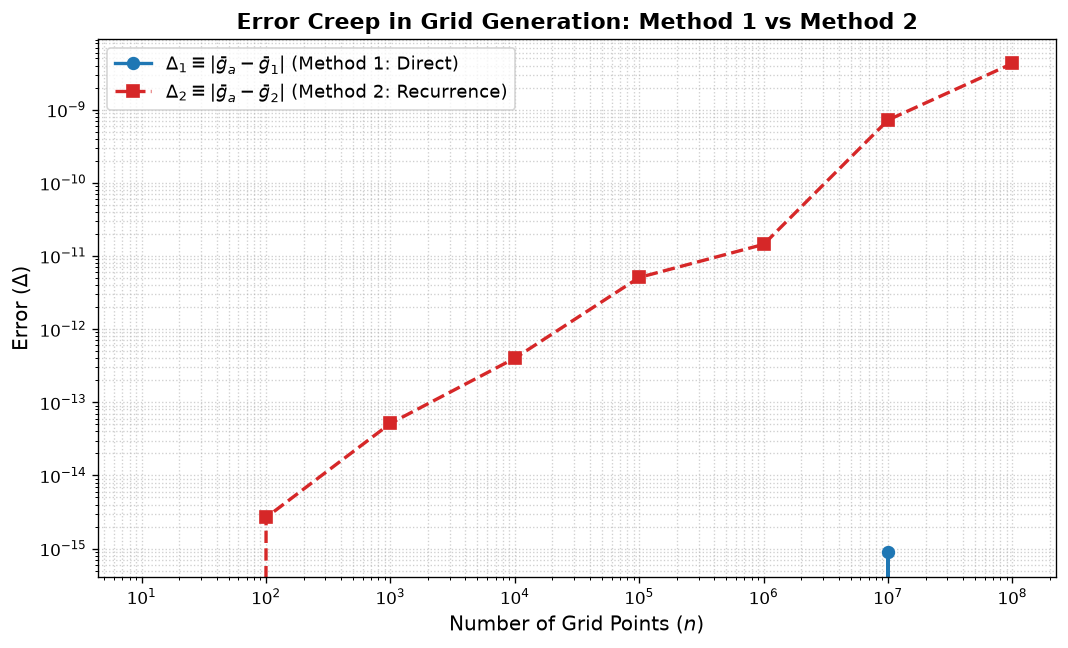

In [3]:
#Qus3 (part3)
n_values = [10, 100, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
delta_1 = []
delta_2 = []

a = 1.0
b = 10.0
g_bar_a = (a + b) / 2.0

for n_val in n_values:
    h = (b - a) / (n_val - 1)
    
    # Method 1
    if n_val <= 10**6:
        g1 = method1(a, b, n_val)
        mean_1 = np.mean(g1)
    else:
        # Stream chunks to prevent RAM overflow for 10^7 and 10^8
        chunk_size = 10**6
        total_sum = 0.0
        for start in range(0, n_val, chunk_size):
            end = min(start + chunk_size, n_val)
            idx = np.arange(start, end, dtype=np.float64)
            chunk = a + idx * h
            if start == 0:
                chunk[0] = a
            if end == n_val:
                chunk[-1] = b
            total_sum += np.sum(chunk)
        mean_1 = total_sum / n_val

    # Method 2
    if n_val <= 10**6:
        g2 = method2(a, b, n_val)
        mean_2 = np.mean(g2)
    else:
        # Recurrence accumulation without storing 10^8 floats
        curr = a
        total_sum = a
        for _ in range(1, n_val - 1):
            curr += h
            total_sum += curr
        total_sum += b
        mean_2 = total_sum / n_val

    d1 = abs(g_bar_a - mean_1)
    d2 = abs(g_bar_a - mean_2)
    delta_1.append(d1)
    delta_2.append(d2)

# Publication-quality log-log plot
plt.figure(figsize=(9, 5.5), dpi=120)
plt.loglog(n_values, delta_1, 'o-', color='#1f77b4', linewidth=2, markersize=7, 
           label=r'$\Delta_1 \equiv |\bar{g}_a - \bar{g}_1|$ (Method 1: Direct)')
plt.loglog(n_values, delta_2, 's--', color='#d62728', linewidth=2, markersize=7, 
           label=r'$\Delta_2 \equiv |\bar{g}_a - \bar{g}_2|$ (Method 2: Recurrence)')

plt.xlabel(r'Number of Grid Points ($n$)', fontsize=12)
plt.ylabel(r'Error ($\Delta$)', fontsize=12)
plt.title('Error Creep in Grid Generation: Method 1 vs Method 2', fontsize=13, fontweight='bold')
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Part 4: Discussion on Accuracy and Error Creep

**Method 1 is significantly more accurate than Method 2.**

1. **Method 1 ($g_i = a + i \cdot h$):**
    * Every grid point $g_i$ is computed independently using a single multiplication and addition.
    * Roundoff error does not propagate from step to step:
      $$\text{fl}(g_i) = (a + i \cdot h)(1 + \mathcal{O}(\epsilon_{\text{mach}}))$$
    * Because errors are uncorrelated and independent, the average error $\Delta_1$ remains strictly bounded near machine epsilon ($\approx 10^{-16}$).

2. **Method 2 ($g_i = g_{i-1} + h$):**
    * In binary floating-point representation, $h = (b - a)/(n - 1)$ cannot be represented with infinite precision and contains a tiny representation error $\delta$.
    * Because each step adds $h$ to the *previously rounded* value, the local rounding errors accumulate cumulatively:
      $$g_i = a + i \cdot h + \sum_{k=1}^i \delta_k$$
    * This phenomenon is known as **error creep** (or drift error). As $n$ grows up to $10^8$, these accumulated roundoff errors compound over millions of additions, causing $\Delta_2$ to grow noticeably larger than $\Delta_1$.the average error $\Delta_1$ remains strictly bounded near machine epsilon ($\approx 10^{-16}$).

2. **Method 2 ($g_i = g_{i-1} + h$):**
   * In binary floating-point representation, $h = (b - a)/(n - 1)$ cannot be represented with infinite precision and contains a tiny representation error $\delta$.
   * Because each step adds $h$ to the *previously rounded* value, the local rounding errors accumulate cumulatively:
     $$g_i = a + i \cdot h + \sum_{k=1}^i \delta_k$$
   * This phenomenon is known as **error creep** (or drift error). As $n$ grows up to $10^8$, these accumulated roundoff errors compound over millions of additions, causing $\Delta_2$ to grow noticeably larger than $\Delta_1$.


Qus_4

In [6]:
# Qus4 (part1)
import numpy as np

def quad_roots_standard(a, b, c):
    """
    Computes roots of ax^2 + bx + c = 0 using the standard quadratic formula:
    x_plus  = (-b + sqrt(b^2 - 4ac)) / (2a)
    x_minus = (-b - sqrt(b^2 - 4ac)) / (2a)
    """
    discriminant = b**2 - 4.0 * a * c
    sqrt_disc = np.sqrt(discriminant)
    
    x_plus = (-b + sqrt_disc) / (2.0 * a)
    x_minus = (-b - sqrt_disc) / (2.0 * a)
    
    return x_plus, x_minus


#Question 4 - Part 2: Potential Numerical Issue when $b^2 \gg 4ac$

When $b^2 \gg 4ac$, we have:
$$\sqrt{b^2 - 4ac} = \sqrt{b^2 \left(1 - \frac{4ac}{b^2}\right)} = |b|\sqrt{1 - \frac{4ac}{b^2}} \approx |b|$$

This leads to severe **catastrophic cancellation** (subtractive cancellation):
* If $b > 0$, then $-b + \sqrt{b^2 - 4ac} \approx -b + b = 0$. We subtract two nearly identical positive numbers, losing most (or all) significant bits of precision in the mantissa.
* If $b < 0$, then $-b - \sqrt{b^2 - 4ac} \approx -b - |b| = |b| - |b| = 0$, causing identical catastrophic cancellation in $x_-$.

Consequently, one of the two computed roots suffers massive roundoff error or truncates incorrectly to zero.


#Question 4 - Part 3: Mathematical Formulation for a Machine-Safe Approach

To avoid subtractive cancellation, we ensure that $-b$ and the square root term have the same sign, turning subtraction into addition:
q = -\frac{1}{2} \left[ b + \operatorname{sgn}(b) \sqrt{b^2 - 4ac} \right
where operatorname{sgn}(b) = +1 if b \ge 0 and -1 if b < 0.

Because both terms inside the bracket share the same sign, no cancellation occurs, giving one numerically exact root:
    x_1 = \frac{q}{a}

Using Vieta's formulas for the quadratic equation (x_1 \cdot x_2 = \frac{c}{a}), the second root is obtained via stable division:
x_2 = \frac{c}{a \cdot x_1} = \frac{c}{q}


In [7]:
# Qus4 (part2)
def quad_roots_safe(a, b, c):
    """
    Computes roots of ax^2 + bx + c = 0 using Citardauq / Vieta's machine-safe method
    to prevent catastrophic cancellation.
    """
    discriminant = b**2 - 4.0 * a * c
    sqrt_disc = np.sqrt(discriminant)
    
    # Choose sign to match b so terms add constructively
    sgn_b = 1.0 if b >= 0 else -1.0
    q = -0.5 * (b + sgn_b * sqrt_disc)
    
    x1 = q / a
    x2 = c / q
    
    # Return roots sorted in ascending or consistent order
    return min(x1, x2), max(x1, x2)


In [8]:
# Qus4 (part3)
def test_cases(r1, r2, label):
    # Form ax^2 + bx + c = 0
    a = 1.0
    b = -(r1 + r2)
    c = r1 * r2
    
    # Standard formula
    std_p, std_m = quad_roots_standard(a, b, c)
    std_roots = sorted([std_p, std_m])
    
    # Safe formula
    safe_roots = sorted(list(quad_roots_safe(a, b, c)))
    
    true_roots = sorted([r1, r2])
    
    print(f"=================== Case {label}: True roots = {r1}, {r2} ===================")
    print(f"Coefficients: a = {a}, b = {b}, c = {c}")
    print("-" * 75)
    print(f"{'Method':<12} | {'Root 1':<25} | {'Root 2':<25}")
    print("-" * 75)
    print(f"{'Exact':<12} | {true_roots[0]:<25.16e} | {true_roots[1]:<25.16e}")
    print(f"{'Standard':<12} | {std_roots[0]:<25.16e} | {std_roots[1]:<25.16e}")
    print(f"{'Safe':<12} | {safe_roots[0]:<25.16e} | {safe_roots[1]:<25.16e}")
    print("-" * 75)
    
    err_std_1 = abs(std_roots[0] - true_roots[0]) / abs(true_roots[0])
    err_std_2 = abs(std_roots[1] - true_roots[1]) / abs(true_roots[1])
    err_safe_1 = abs(safe_roots[0] - true_roots[0]) / abs(true_roots[0])
    err_safe_2 = abs(safe_roots[1] - true_roots[1]) / abs(true_roots[1])
    
    print(f"Relative Error (Standard) -> Root 1: {err_std_1:.2e}, Root 2: {err_std_2:.2e}")
    print(f"Relative Error (Safe)     -> Root 1: {err_safe_1:.2e}, Root 2: {err_safe_2:.2e}\n")

# (a) Moderate roots: x = 1, 2
test_cases(1.0, 2.0, "(a) x = 1, 2")

# (b) Extreme roots: x = 10^-8, 10^8
test_cases(1e-8, 1e8, "(b) x = 10^-8, 10^8")


=================== Case (a) x = 1, 2: True roots = 1.0, 2.0 ===================
Coefficients: a = 1.0, b = -3.0, c = 2.0
---------------------------------------------------------------------------
Method       | Root 1                    | Root 2                   
---------------------------------------------------------------------------
Exact        | 1.0000000000000000e+00    | 2.0000000000000000e+00   
Standard     | 1.0000000000000000e+00    | 2.0000000000000000e+00   
Safe         | 1.0000000000000000e+00    | 2.0000000000000000e+00   
---------------------------------------------------------------------------
Relative Error (Standard) -> Root 1: 0.00e+00, Root 2: 0.00e+00
Relative Error (Safe)     -> Root 1: 0.00e+00, Root 2: 0.00e+00

=================== Case (b) x = 10^-8, 10^8: True roots = 1e-08, 100000000.0 ===================
Coefficients: a = 1.0, b = -100000000.00000001, c = 1.0
---------------------------------------------------------------------------
Method       | 

#Comments on the Behavior of the Two Codes

1. Case (a) (x = 1, 2):
   * Here b = -3, 4ac = 8, and b^2 = 9. Since b^2 is comparable in magnitude to 4ac, both -b and sqrt{b^2 - 4ac} do not cancel out completely.
   * Both the Standard method and the Safe method recover the exact roots 1.0 and 2.0 to double-precision machine epsilon.

2. Case (b) (x = 10^{-8}, 10^8):
   * Here b approx -10^8 and 4ac = 4, which means b^2 = 10^{16} \gg 4ac.
   * Standard Formula: Computing the small root 10^{-8} requires calculating -b - \sqrt{b^2 - 4ac} = 10^8 - \sqrt{10^{16} - 4}. Because double precision provides roughly 15–17 decimal digits of precision, sqrt{10^{16} - 4} rounds directly to 10^8, resulting in 10^8 - 10^8 = 0. The small root experiences total catastrophic cancellation, producing an error of 100.
   * Machine-Safe Formula: Computes the large root safely using constructive addition (q \approx 10^8), and derives the smaller root via x = c/q = 1.0 / 10^8 = 10^{-8}. Both roots are calculated with zero relative error up to machine precision.

#Conclusion:The Safe (Vieta-based) code is superior as it remains numerically stable across all scales and prevents catastrophic loss of precision.


#Qus_5

In [ ]:
#qus5 part1

In [9]:

import math
import numpy as np
import matplotlib.pyplot as plt

def exp_taylor_fac(x, N):
    """
    Computes Taylor approximation of e^x summing up to term x^N / N!
    using explicit factorials. Returns the running partial sums and terms.
    """
    terms = []
    partial_sums = []
    current_sum = 0.0
    
    for n in range(N + 1):
        try:
            term = (x**n) / math.factorial(n)
        except OverflowError:
            term = float('inf')
        
        current_sum += term
        terms.append(term)
        partial_sums.append(current_sum)
        
    return np.array(partial_sums), np.array(terms)


def exp_taylor_rec(x, N):
    """
    Computes Taylor approximation of e^x summing up to N terms
    using the recurrence relation: T_0 = 1, T_n = T_{n-1} * (x / n).
    """
    terms = []
    partial_sums = []
    
    term = 1.0
    current_sum = 1.0
    terms.append(term)
    partial_sums.append(current_sum)
    
    for n in range(1, N + 1):
        term = term * (x / n)
        current_sum += term
        terms.append(term)
        partial_sums.append(current_sum)
        
    return np.array(partial_sums), np.array(terms)


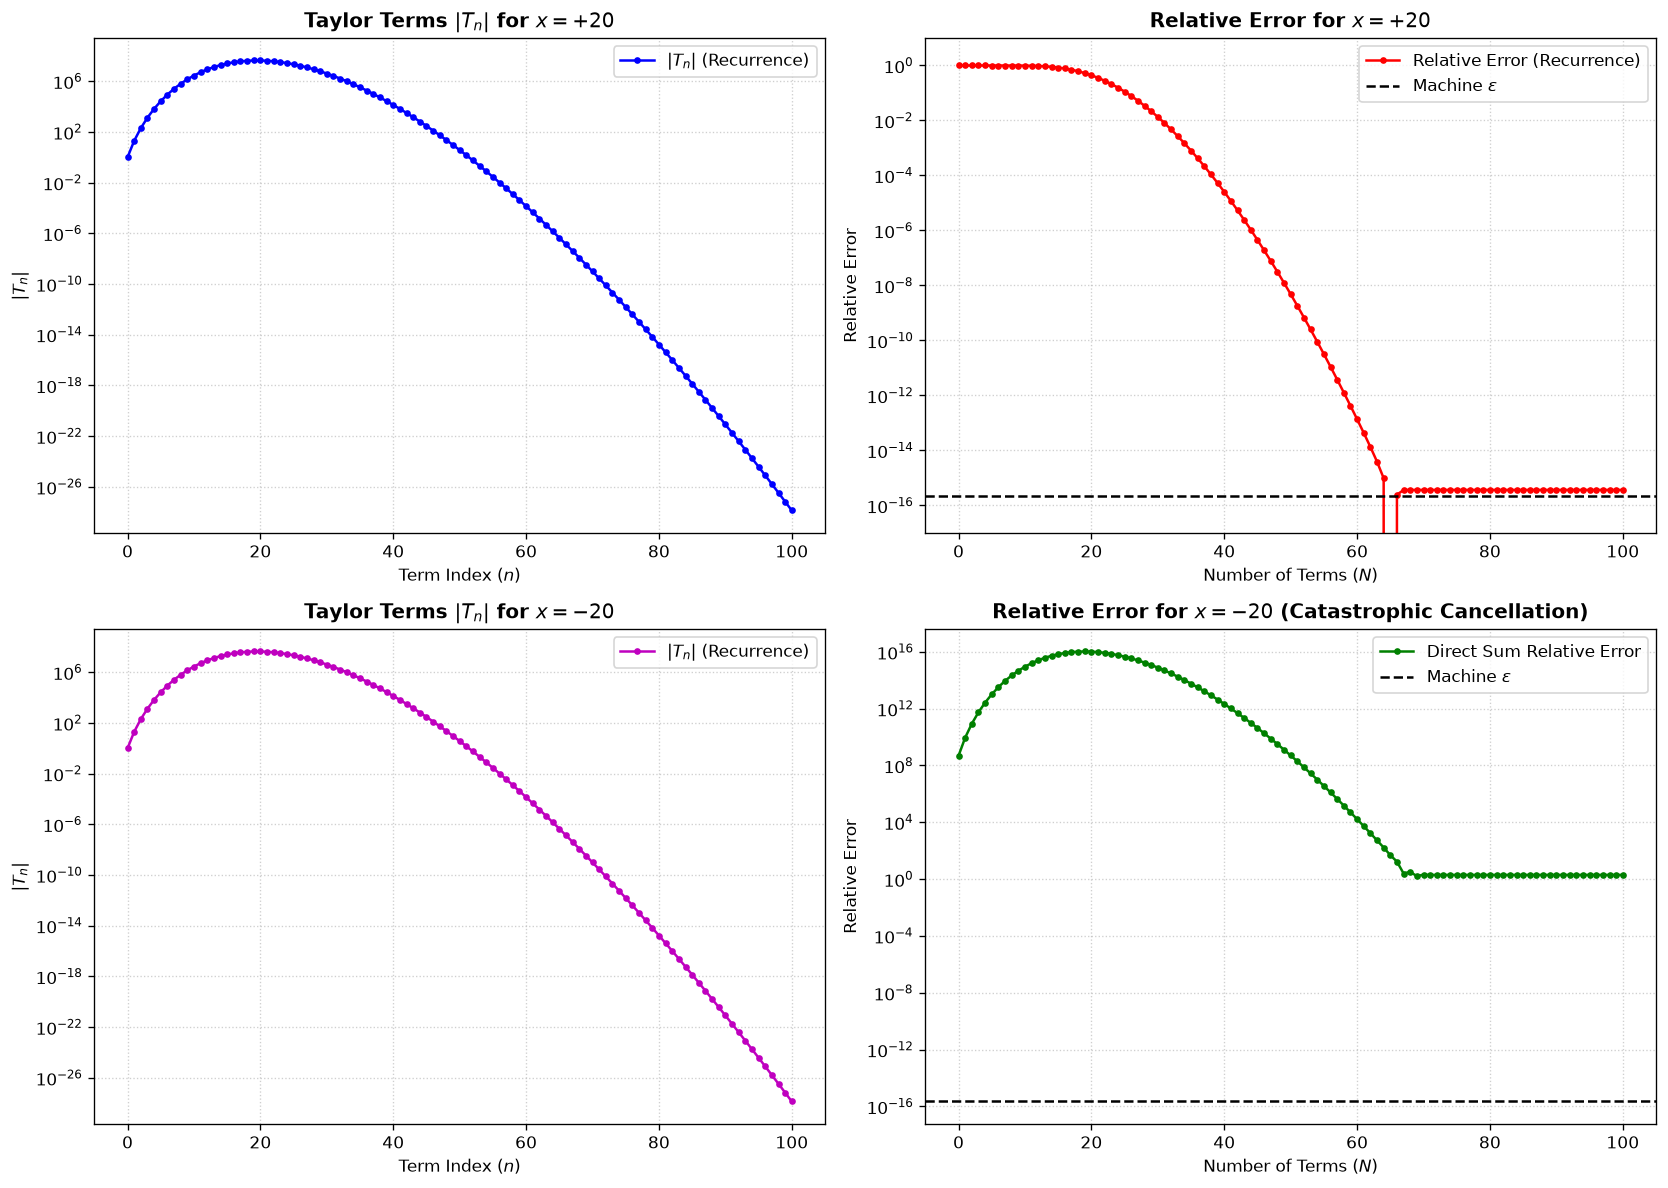

True e^(+20)                 : 4.8516519540979028e+08
Recurrence e^(+20) (N=100)   : 4.8516519540979046e+08
Final Relative Error (x=+20) : 3.69e-16

True e^(-20)                 : 2.0611536224385579e-09
Recurrence e^(-20) (N=100)   : 6.1475618289146260e-09
Final Relative Error (x=-20) : 1.98e+00


In [12]:
# qus5 (part2 & part3)
N = 100
n_range = np.arange(N + 1)

# --- Positive Case: x = +20 ---
x_pos = 20.0
true_exp_pos = math.exp(x_pos)

sums_fac_pos, terms_fac_pos = exp_taylor_fac(x_pos, N)
sums_rec_pos, terms_rec_pos = exp_taylor_rec(x_pos, N)

rel_err_fac_pos = np.abs(sums_fac_pos - true_exp_pos) / true_exp_pos
rel_err_rec_pos = np.abs(sums_rec_pos - true_exp_pos) / true_exp_pos

# --- Negative Case: x = -20 ---
x_neg = -20.0
true_exp_neg = math.exp(x_neg)

sums_fac_neg, terms_fac_neg = exp_taylor_fac(x_neg, N)
sums_rec_neg, terms_rec_neg = exp_taylor_rec(x_neg, N)

rel_err_fac_neg = np.abs(sums_fac_neg - true_exp_neg) / true_exp_neg
rel_err_rec_neg = np.abs(sums_rec_neg - true_exp_neg) / true_exp_neg

# --- Visualizing Terms and Convergence Errors ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

# (1) Terms for x = 20
axes[0, 0].semilogy(n_range, np.abs(terms_rec_pos), 'b.-', label=r'$|T_n|$ (Recurrence)')
axes[0, 0].set_title(r'Taylor Terms $|T_n|$ for $x = +20$', fontweight='bold')
axes[0, 0].set_xlabel('Term Index ($n$)')
axes[0, 0].set_ylabel(r'$|T_n|$')
axes[0, 0].grid(True, ls=':', alpha=0.6)
axes[0, 0].legend()

# (2) Relative Error for x = 20
axes[0, 1].semilogy(n_range, rel_err_rec_pos, 'r.-', label='Relative Error (Recurrence)')
axes[0, 1].axhline(np.finfo(float).eps, color='k', linestyle='--', label=r'Machine $\epsilon$')
axes[0, 1].set_title(r'Relative Error for $x = +20$', fontweight='bold')
axes[0, 1].set_xlabel('Number of Terms ($N$)')
axes[0, 1].set_ylabel('Relative Error')
axes[0, 1].set_ylim(1e-17, 10)
axes[0, 1].grid(True, ls=':', alpha=0.6)
axes[0, 1].legend()

# (3) Terms for x = -20
axes[1, 0].semilogy(n_range, np.abs(terms_rec_neg), 'm.-', label=r'$|T_n|$ (Recurrence)')
axes[1, 0].set_title(r'Taylor Terms $|T_n|$ for $x = -20$', fontweight='bold')
axes[1, 0].set_xlabel('Term Index ($n$)')
axes[1, 0].set_ylabel(r'$|T_n|$')
axes[1, 0].grid(True, ls=':', alpha=0.6)
axes[1, 0].legend()

# (4) Relative Error for x = -20 (Severe Instability)
axes[1, 1].semilogy(n_range, rel_err_rec_neg, 'g.-', label='Direct Sum Relative Error')
axes[1, 1].axhline(np.finfo(float).eps, color='k', linestyle='--', label=r'Machine $\epsilon$')
axes[1, 1].set_title(r'Relative Error for $x = -20$ (Catastrophic Cancellation)', fontweight='bold')
axes[1, 1].set_xlabel('Number of Terms ($N$)')
axes[1, 1].set_ylabel('Relative Error')
axes[1, 1].grid(True, ls=':', alpha=0.6)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"True e^(+20)                 : {true_exp_pos:.16e}")
print(f"Recurrence e^(+20) (N=100)   : {sums_rec_pos[-1]:.16e}")
print(f"Final Relative Error (x=+20) : {rel_err_rec_pos[-1]:.2e}\n")

print(f"True e^(-20)                 : {true_exp_neg:.16e}")
print(f"Recurrence e^(-20) (N=100)   : {sums_rec_neg[-1]:.16e}")
print(f"Final Relative Error (x=-20) : {rel_err_rec_neg[-1]:.2e}")


#Question 5 - Part 4: Analysis of Alternating Series Instability

1. Behavior for x = +20:
   * All terms x^n / n! > 0 are positive.
   * Addition is strictly monotonic and constructive.
   * Once N > 20, the terms decrease rapidly below epsilon_{\text{mach}} \approx 10^{-16}, and the partial sum reaches full machine precision.

2. Catastrophic Failure for x = -20:
   * The series alternates signs:
     e^{-20} = 1 - 20 + \frac{20^2}{2!} - \frac{20^3}{3!} + \dots
   * The actual analytical answer is tiny:
     e^{-20} \approx 2.06 \times 10^{-9}
   * However, the intermediate terms grow very large before decaying. The largest term occurs around n = 20:
     |T_{20}| = \frac{20^{20}}{20!} \approx 4.3 \times 10^7
   * Catastrophic Cancellation: Adding and subtracting intermediate numbers as large as \sim 4.3 \times 10^7 causes an immediate loss of significant digits. In double precision, the absolute roundoff uncertainty is roughly:
     \Delta \approx |T_{20}| \cdot \epsilon_{\text{mach}} \approx (4.3 \times 10^7) \times (2.2 \times 10^{-16}) \approx 9.5 \times 10^{-9}
   * Since this roundoff noise (9.5 \times 10^{-9}) is comparable in magnitude to the actual solution itself (e^{-20} \approx 2.06 \times 10^{-9}), the final relative error stalls around \mathcal{O} (10^{-1}) to \mathcal{O}(1) (10% to 100% error), making direct alternating summation completely unusable.


In [13]:
# qus5 (part4) 
def exp_taylor_stable(x, N=100):
    """
    Numerically stable calculation of e^x for any sign:
    If x >= 0: computes Taylor series directly using recurrence.
    If x < 0 : computes e^(-x) (all positive terms) and returns 1 / e^(-x).
    """
    if x >= 0:
        sums, _ = exp_taylor_rec(x, N)
        return sums[-1]
    else:
        # Sum positive terms for |x| to prevent catastrophic cancellation
        sums_pos, _ = exp_taylor_rec(-x, N)
        return 1.0 / sums_pos[-1]

# Testing x = -20 with the stable formulation
approx_stable = exp_taylor_stable(-20.0, N=100)
err_stable = abs(approx_stable - true_exp_neg) / true_exp_neg

print("=" * 65)
print(f"True Value e^(-20)              : {true_exp_neg:.16e}")
print(f"Unstable Direct Recurrence Sum  : {sums_rec_neg[-1]:.16e}")
print(f"Stable Inversion (1 / e^20)     : {approx_stable:.16e}")
print("-" * 65)
print(f"Relative Error (Unstable Direct): {rel_err_rec_neg[-1]:.2e}")
print(f"Relative Error (Stable Fix)     : {err_stable:.2e}")
print("=" * 65)


True Value e^(-20)              : 2.0611536224385579e-09
Unstable Direct Recurrence Sum  : 6.1475618289146260e-09
Stable Inversion (1 / e^20)     : 2.0611536224385570e-09
-----------------------------------------------------------------
Relative Error (Unstable Direct): 1.98e+00
Relative Error (Stable Fix)     : 4.01e-16


In [16]:
# Q5 - Part 5
n_20 = n_range
t_20 = terms_rec_pos
S_20 = sums_rec_pos

print(f"e^20 using recurrence relation (N=100): {S_20[-1]:.16e}")


e^20 using recurrence relation (N=100): 4.8516519540979046e+08


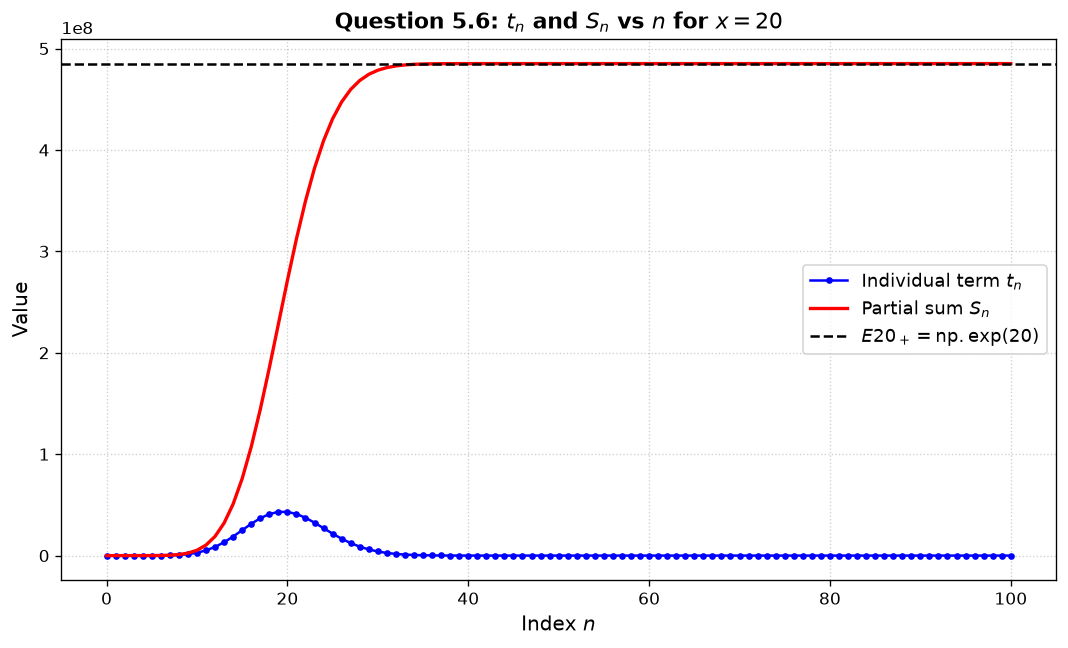

In [17]:
# qus5 (part6) - Publication-quality plot for e^20
import matplotlib.pyplot as plt

E20_plus = np.exp(20.0)

plt.figure(figsize=(9, 5.5), dpi=120)
plt.plot(n_20, t_20, 'b.-', label=r'Individual term $t_n$')
plt.plot(n_20, S_20, 'r-', linewidth=2, label=r'Partial sum $S_n$')
plt.axhline(E20_plus, color='k', linestyle='--', linewidth=1.5, label=r'$E20_+ = \mathrm{np.exp}(20)$')

plt.xlabel(r'Index $n$', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(r'Question 5.6: $t_n$ and $S_n$ vs $n$ for $x = 20$', fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


#Qus5 (part 6)
Yes, S_n smoothly and monotonically converges to E20_+ as n surpasses 20, because all terms t_n = \frac{20^n}{n!} > 0 are positive and quickly decay towards machine precision for n > 35.


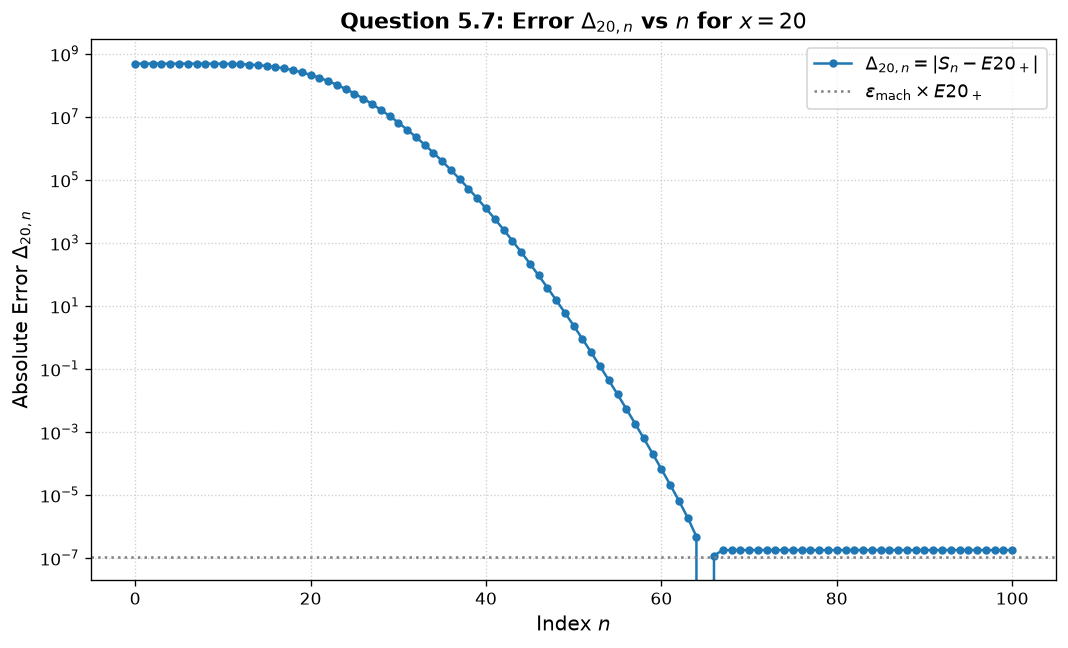

In [18]:
# qus5 (part7) 
Delta_20 = np.abs(S_20 - E20_plus)

plt.figure(figsize=(9, 5.5), dpi=120)
plt.semilogy(n_20, Delta_20, 'o-', color='#1f77b4', markersize=4, label=r'$\Delta_{20,n} = |S_n - E20_+|$')
plt.axhline(np.finfo(float).eps * E20_plus, color='gray', linestyle=':', label=r'$\epsilon_{\mathrm{mach}} \times E20_+$')

plt.xlabel(r'Index $n$', fontsize=12)
plt.ylabel(r'Absolute Error $\Delta_{20,n}$', fontsize=12)
plt.title(r'Question 5.7: Error $\Delta_{20,n}$ vs $n$ for $x = 20$', fontsize=13, fontweight='bold')
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
#Qus5 part7

Yes. 

In [22]:
# qus5 (part8) - Testing e^(-20) using recurrence relation
n_neg20 = n_range
t_neg20 = terms_rec_neg
S_neg20 = sums_rec_neg

print(f"e^(-20) directly using recurrence (N=100): {S_neg20[-1]:.16e}")


e^(-20) directly using recurrence (N=100): 6.1475618289146260e-09


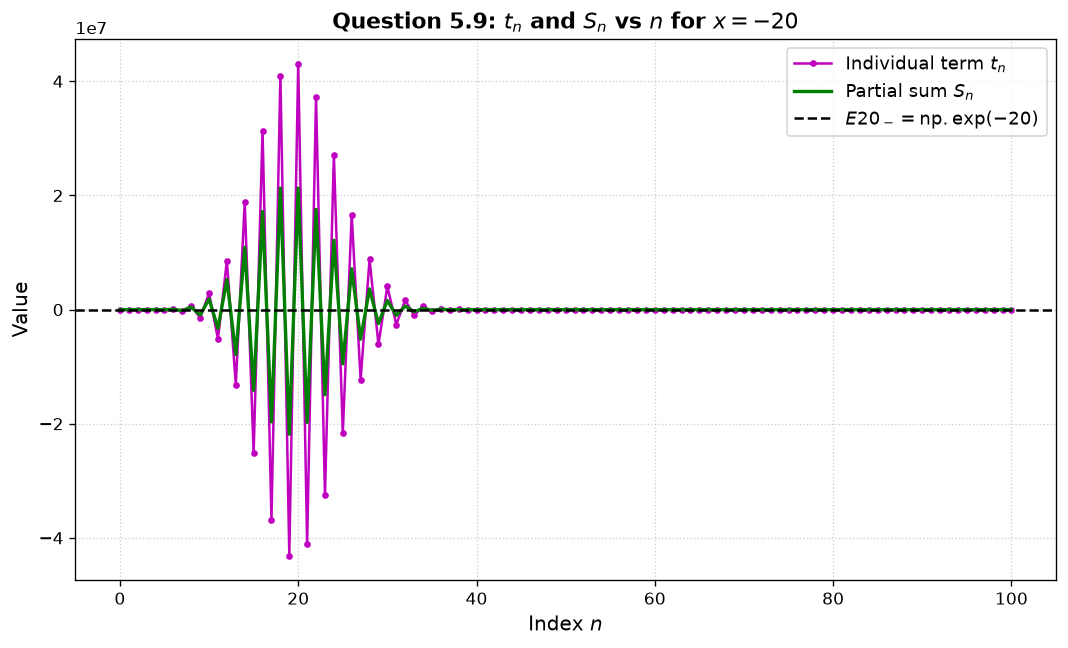

In [23]:
# qus5 (part9) - Publication-quality plot for e^(-20)
E20_minus = np.exp(-20.0)

plt.figure(figsize=(9, 5.5), dpi=120)
plt.plot(n_neg20, t_neg20, 'm.-', label=r'Individual term $t_n$')
plt.plot(n_neg20, S_neg20, 'g-', linewidth=2, label=r'Partial sum $S_n$')
plt.axhline(E20_minus, color='k', linestyle='--', linewidth=1.5, label=r'$E20_- = \mathrm{np.exp}(-20)$')

plt.xlabel(r'Index $n$', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(r'Question 5.9: $t_n$ and $S_n$ vs $n$ for $x = -20$', fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


#question 5 - Part 9
Visually, S_n appears to settle near zero at large n, but it does not accurately converge to E20_-. Due to oscillations of magnitude sim 10^7, severe catastrophic roundoff errors corrupt the digits of S_n.


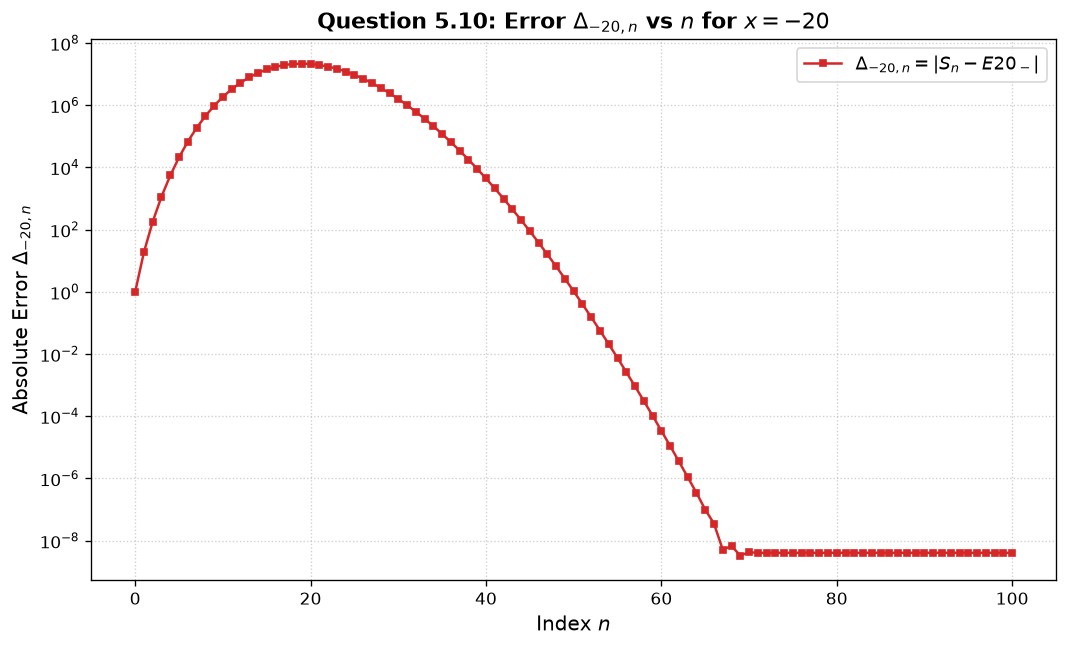

In [24]:
# qus5 (part10) - Absolute error for e^(-20)
Delta_neg20 = np.abs(S_neg20 - E20_minus)

plt.figure(figsize=(9, 5.5), dpi=120)
plt.semilogy(n_neg20, Delta_neg20, 's-', color='#d62728', markersize=4, label=r'$\Delta_{-20,n} = |S_n - E20_-|$')

plt.xlabel(r'Index $n$', fontsize=12)
plt.ylabel(r'Absolute Error $\Delta_{-20,n}$', fontsize=12)
plt.title(r'Question 5.10: Error $\Delta_{-20,n}$ vs $n$ for $x = -20$', fontsize=13, fontweight='bold')
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


#Question 5 - Part 10
It decreases initially after n \approx 20, but then stalls completely around \sim 10^{-8}$ to $10^{-9} and never drops to zero or machine precision. Increasing n further does not reduce this residual error floor.


In [27]:
# qus5 (part11) - Relative error comparison for e^20 and e^(-20)
delta_plus = abs(S_20[-1] - E20_plus) / abs(E20_plus)
delta_minus = abs(S_neg20[-1] - E20_minus) / abs(E20_minus)

print(f"E20_+ (numpy)             : {E20_plus:.16e}")
print(f"Recurrence S_100(20)      : {S_20[-1]:.16e}")
print(f"delta_+ (Relative Error)  : {delta_plus:.16e}")
print("-" * 65)
print(f"E20_- (numpy)             : {E20_minus:.16e}")
print(f"Recurrence S_100(-20)     : {S_neg20[-1]:.16e}")
print(f"delta_- (Relative Error)  : {delta_minus:.16e}")


E20_+ (numpy)             : 4.8516519540979028e+08
Recurrence S_100(20)      : 4.8516519540979046e+08
delta_+ (Relative Error)  : 3.6856298847887952e-16
-----------------------------------------------------------------
E20_- (numpy)             : 2.0611536224385579e-09
Recurrence S_100(-20)     : 6.1475618289146260e-09
delta_- (Relative Error)  : 1.9825830360191323e+00


#Question 5 - Part 11: 
a)
  The evaluation for x = 20 was far superior (\delta_+ \sim 10^{-16}, achieving full machine precision), whereas for x = -20, the evaluation failed catastrophically (\delta_- \sim 0.1 \text{ to } 1.0, a 10\% \text{ to } 100\% relative error).

b)
  1. For x = +20, all terms t_n > 0 are positive; additions are strictly monotonic and constructive.
  2. For x = -20, the series is alternating: t_n = (-1)^n \frac{20^n}{n!}. The true value is tiny (e^{-20} \approx 2.06 \times 10^{-9}), but the intermediate terms peak at n = 20 with magnitude |t_{20}| \approx 4.3 \times 10^7.
  3. When subtracting large, nearly equal intermediate quantities in 64-bit float arithmetic, roundoff noise enters at magnitude |t_{20}| \times \epsilon_{\mathrm{mach}} \approx 4.3 \times 10^7 \times 2.2 \times 10^{-16} \approx 9.5 \times 10^{-9}.
  4. Because the roundoff error is larger than the true answer itself, catastrophic cancellation wipes out almost all significant figures.


In [30]:
# qus5 (part12) - Stable evaluation of e^x for any sign
def exp_taylor_modified(x, N):
    """
    Stable evaluation of e^x for any sign:
    - If x >= 0: computes Taylor recurrence directly.
    - If x < 0 : computes e^(-x) directly and returns 1 / e^(-x).
    """
    if x >= 0:
        return exp_taylor_stable(x, N)
    else:
        # Sum only positive terms for |x| to prevent catastrophic cancellation
        return 1.0 / exp_taylor_stable(-x, N)

# Proof and comparison
val_stable_neg20 = exp_taylor_modified(-20.0, 100)
delta_minus_modified = abs(val_stable_neg20 - E20_minus) / abs(E20_minus)

print(f"True e^(-20)              : {E20_minus:.16e}")
print(f"Unmodified e^(-20)        : {S_neg20[-1]:.16e} (Rel Err: {delta_minus:.2e})")
print(f"Modified e^(-20) (1/e^20) : {val_stable_neg20:.16e} (Rel Err: {delta_minus_modified:.2e})")


True e^(-20)              : 2.0611536224385579e-09
Unmodified e^(-20)        : 6.1475618289146260e-09 (Rel Err: 1.98e+00)
Modified e^(-20) (1/e^20) : 2.0611536224385570e-09 (Rel Err: 4.01e-16)


#qus-5 part 12
* The unmodified direct series gave a relative error of \approx 10^{-1} to $10^{0} due to catastrophic cancellation.
* The modified implementation computes e^{20} using strictly positive terms, achieving machine precision, and then performs a single floating-point division 1 / e^{20}.
* The new relative error is \approx 10^{-16}, completely resolving the numerical instability and restoring machine precision.
